# Phân tích khám phá dữ liệu Pima Diabetes

## 1. Định nghĩa vấn đề (Define Problem)
+ **Mô tả**: Dự đoán khả năng mắc tiểu đường dựa trên các chỉ số y tế của bệnh nhân nữ Pima Indians.
+ **Dữ liệu vào**: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age
+ **Kết quả**: Outcome (0: không mắc, 1: mắc tiểu đường)

### Câu hỏi nghiên cứu (Research Questions)
1. Mô hình nào trong LR/DT/RF/SVM đạt F1-score và ROC-AUC cao nhất trên tập test?
2. Đặc trưng nào ảnh hưởng nhiều nhất đến dự đoán tiểu đường theo feature importance của Random Forest?
3. Việc xử lý mất cân bằng lớp bằng SMOTE có cải thiện Recall của lớp dương tính không?

### Độ đo đánh giá chính
Trong bài toán dự đoán tiểu đường với dữ liệu Pima có mất cân bằng lớp (khoảng 65/35), chỉ dùng Accuracy có thể gây đánh giá sai lệch vì mô hình thiên về lớp đa số vẫn có thể đạt điểm cao.

- **F1-score** được chọn làm metric chính vì cân bằng giữa Precision và Recall, phù hợp khi cần giảm bỏ sót ca dương tính nhưng vẫn kiểm soát dự đoán dương tính sai.
- **ROC-AUC** được chọn để đánh giá khả năng phân tách hai lớp trên nhiều ngưỡng quyết định khác nhau, thay vì phụ thuộc vào một ngưỡng cố định.
- Kết hợp **F1-score + ROC-AUC** giúp đánh giá toàn diện hơn hiệu năng mô hình trong bối cảnh dữ liệu mất cân bằng, đáng tin cậy hơn so với chỉ dùng Accuracy.

## 2. Chuẩn bị vấn đề (Prepare Problem)
### 2.1. Khai báo thư viện (Load Libraries)

In [13]:
# Load libraries
import os, sys
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import warnings

%matplotlib inline
warnings.filterwarnings("ignore")

### 2.2. Nạp dữ liệu (Load Dataset)

In [14]:
# Load dataset
data_path = "../data/diabetes.csv"
col_names = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
 ]

# Tuong thich ca 2 truong hop: file co header hoac khong co header
df_dataset = pd.read_csv(data_path)
if 'Outcome' not in df_dataset.columns:
    df_dataset = pd.read_csv(data_path, header=None, names=col_names)

print(f'+ Shape: {df_dataset.shape}')
display.display(df_dataset.head(5))

+ Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3. Phân tích khám phá dữ liệu (Exploration Analyze Data - EDA)
### 3.1. Thống kê mô tả (Descriptive Statistics) - Ungraphic Approach

#### (1) **Hiển thị một số thông tin về dữ liệu**
+ Số dòng, số cột của dữ liệu
+ Kiểu dữ liệu của từng cột
+ 5 dòng đầu và 5 dòng cuối của bảng dữ liệu
+ Thông tin chung về dữ liệu

In [15]:
# shape
print(f'+ Shape: {df_dataset.shape}')
# types
print(f'+ Data Types: \n{df_dataset.dtypes}')
# head, tail
print('+ Contents:')
display.display(df_dataset.head(5))
display.display(df_dataset.tail(5))
# info
df_dataset.info()

+ Shape: (768, 9)
+ Data Types: 
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object
+ Contents:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


#### (2) **Kiểm tra tính toàn vẹn của dữ liệu**
+ Dữ liệu có bị trùng lặp không?
+ Dữ liệu có tồn tại giá trị Null/NaN không?
+ Kiểm tra nhanh tần suất lớp Outcome (0/1).

In [16]:
print('='*5, 'Checking Null', '='*5)
display.display(df_dataset.isnull().sum())
has_null = df_dataset.isnull().sum().any()
print(f'+ Có giá trị Null: {has_null}')

print('='*5, 'Checking NaN', '='*5)
display.display(df_dataset.isna().sum())
has_nan = df_dataset.isna().sum().any()
print(f'+ Có giá trị NaN: {has_nan}')

print('='*5, 'Checking Duplicated', '='*5)
n_duplicated = df_dataset.duplicated(keep=False).sum()
print(f'+ Số dòng trùng: {n_duplicated}')
if n_duplicated > 0:
    display.display(df_dataset[df_dataset.duplicated(keep=False)])

print('='*5, 'Outcome Distribution', '='*5)
display.display(df_dataset['Outcome'].value_counts())

===== Checking Null =====


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

+ Có giá trị Null: False
===== Checking NaN =====


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

+ Có giá trị NaN: False
===== Checking Duplicated =====
+ Số dòng trùng: 0
===== Outcome Distribution =====


Outcome
0    500
1    268
Name: count, dtype: int64

#### (3) **Các tính chất thống kê trên dữ liệu số**
+ Count, Mean, Standard Deviation, Minimum Value
+ 25th Percentile, 50th Percentile (Median), 75th Percentile, Maximum Value

In [17]:
description = df_dataset.describe().T
display.display(description)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


#### (4) **Phân tích giá trị 0 phi lý ở các cột y tế**
Trong bộ dữ liệu Pima, giá trị 0 ở một số cột y tế là **không hợp lý về mặt sinh học**:
- Glucose: đường huyết không thể bằng 0 ở người sống.
- BloodPressure: huyết áp tâm trương bằng 0 là phi lý.
- SkinThickness: độ dày nếp gấp da bằng 0 thường là thiếu đo đạc.
- Insulin: insulin bằng 0 trong ngữ cảnh này thường là thiếu dữ liệu.
- BMI: BMI bằng 0 là không thể xảy ra.

Vì vậy, các giá trị 0 này thường được xem là **missing values ngụy trang** và cần thay thế trước khi mô hình hóa.

In [18]:
zero_invalid_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
zero_counts = (df_dataset[zero_invalid_cols] == 0).sum()
zero_ratio = (zero_counts / len(df_dataset) * 100).round(2)

df_zero_summary = pd.DataFrame({
    'zero_count': zero_counts,
    'zero_ratio_percent': zero_ratio
}).sort_values('zero_count', ascending=False)

display.display(df_zero_summary)

,zero_count,zero_ratio_percent
Insulin,374,48.70
SkinThickness,227,29.56
BloodPressure,35,4.56
BMI,11,1.43
Glucose,5,0.65


**Lý do xử lý**:
- Nếu giữ nguyên 0 phi lý, phân phối dữ liệu bị méo mạnh và làm sai lệch thống kê.
- Với bài toán phân lớp y tế, nên thay 0 phi lý bằng NaN rồi điền trung vị (median) để giảm ảnh hưởng ngoại lệ.
- Median ổn định hơn mean khi phân phối lệch, phù hợp dữ liệu y tế.

In [19]:
df_clean = df_dataset.copy()
df_clean[zero_invalid_cols] = df_clean[zero_invalid_cols].replace(0, np.nan)

for col in zero_invalid_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print('Số lượng giá trị 0 phi lý trước xử lý:')
display.display((df_dataset[zero_invalid_cols] == 0).sum())
print('Số lượng giá trị 0 phi lý sau xử lý:')
display.display((df_clean[zero_invalid_cols] == 0).sum())

Số lượng giá trị 0 phi lý trước xử lý:


Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Số lượng giá trị 0 phi lý sau xử lý:


Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

### 3.2. Hiển thị dữ liệu (Visualize Data) - Graphic Approach
#### (1) Countplot của nhãn phân lớp (Outcome)

Outcome
0    500
1    268
Name: count, dtype: int64


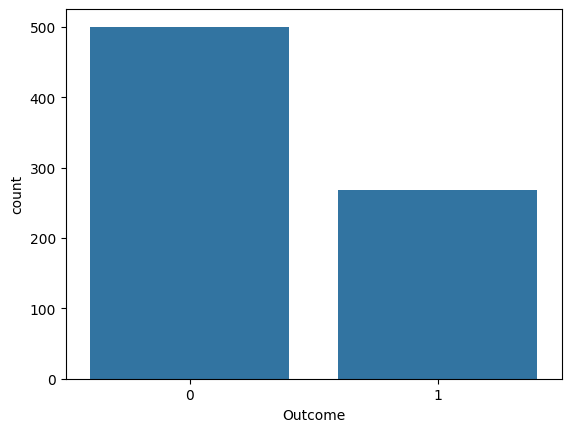

In [20]:
# seaborn - style giống mẫu (dùng cấu hình mặc định)
sns.countplot(x=df_dataset['Outcome']);
print(df_dataset['Outcome'].value_counts())

#### (2) Heatmap tương quan giữa các thuộc tính

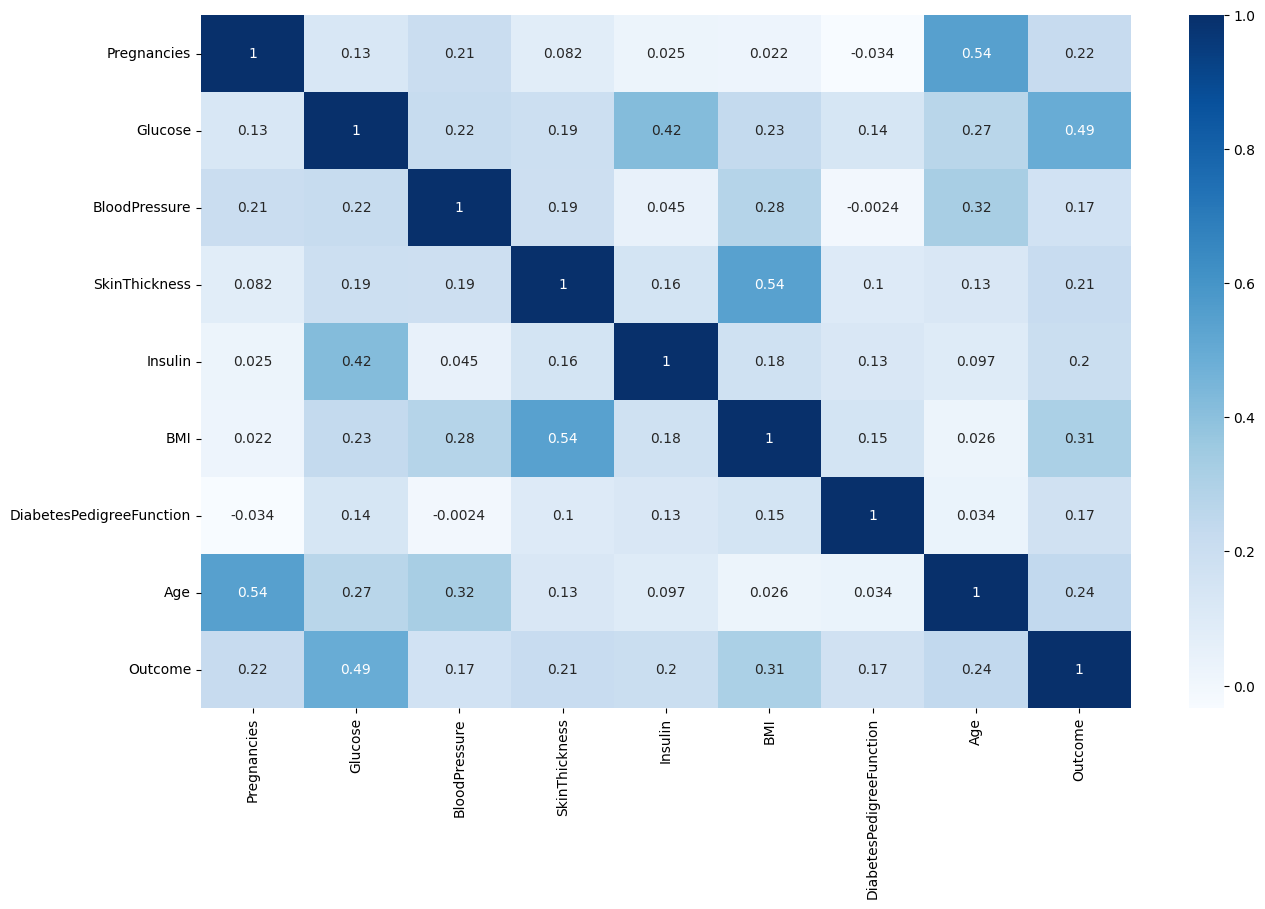

In [21]:
fig = plt.figure(figsize=(15,9))
sns.heatmap(df_clean.corr(), cmap='Blues', annot=True);

**Nhận xét**:
- Heatmap cho thấy Glucose và BMI có tương quan dương đáng kể với Outcome.
- Sau khi thay 0 phi lý bằng median, ma trận tương quan ổn định hơn và phản ánh dữ liệu thực tế tốt hơn.
- Countplot cho thấy bài toán có xu hướng lệch nhẹ về lớp Outcome = 0.